# k-clique density on Facebook

This notebook explores **k-clique count** and **k-clique density** on the Facebook ground-truth graph. The goal is to distinguish triangle closure from dense k-node structure. we'll use 4-clique as a starting point.

## Metric definition

Let $K_4(G)$ be the set of 4-cliques in $G$. Then

$$\delta_4(G)=\frac{|K_4(G)|}{\binom{|V|}{4}}.$$

Interpretation: among all 4-node subsets, how often do we see a fully connected group of four?

In [17]:

from pathlib import Path
import sys
import math
import itertools
import shutil

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'metrics.py').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR.parent

sys.path.insert(0, str(NOTEBOOK_DIR))
from metrics import (
    load_graph,
    k_clique_density_and_count,
    enumerate_k_cliques,
)

DATA_PATH = NOTEBOOK_DIR.parent / 'data' / 'gt_txt' / 'facebook.txt'
G = load_graph(DATA_PATH)
print(f'Loaded {DATA_PATH.name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')


Loading graph: 71890it [00:00, 718856.12it/s]

Loading graph: 88234it [00:00, 711272.80it/s]


Loaded facebook.txt: 4039 nodes, 88234 edges


In [3]:

def induced_ego_subgraph(G, center=None, radius=1, max_nodes=40):
    if center is None:
        center = max(G.degree, key=lambda x: x[1])[0]
    nodes = set(nx.single_source_shortest_path_length(G, center, cutoff=radius).keys())
    H = G.subgraph(nodes).copy()
    if H.number_of_nodes() > max_nodes:
        nbrs = sorted(H.nodes(), key=lambda u: (-G.degree[u], u))[:max_nodes]
        H = G.subgraph(nbrs).copy()
    return center, H


def edge_df(G):
    return pd.DataFrame(sorted((min(u,v), max(u,v)) for u,v in G.edges()), columns=['u','v'])


In [4]:
d4, k4 = k_clique_density_and_count(G, 4) # k_clique_density_and_count returns a tuple of (density, count)
pd.DataFrame([
    {'metric': '4-clique count', 'value': k4},
    {'metric': '4-clique density', 'value': d4},
])

Processing nodes:   0%|          | 0/4039 [00:00<?, ?it/s]

Processing nodes: 100%|██████████| 4039/4039 [00:45<00:00, 89.04it/s]  


,metric,value
0,4-clique count,3.000467e+07
1,4-clique density,2.709880e-06


## Small subgraph example

On a small induced subgraph, we can list 4-cliques explicitly.

In [18]:
def ego_k4_summary(
    G: nx.Graph,
    radius: int = 1,
    min_degree: int = 4,
    max_degree: int = 40,
    min_k4: int = 3,
    max_k4: int = 12,
    max_ego_nodes: int = 40,
    limit: int = 25,
):
    """
    Search for nodes whose ego graph has a manageable number of 4-cliques.
    Returns a dataframe of candidate centers.
    """
    rows = []

    # moderate-degree nodes are more likely to be interpretable
    candidates = [u for u, d in G.degree() if min_degree <= d <= max_degree]

    for center in candidates:
        H = nx.ego_graph(G, center, radius=radius)

        if H.number_of_nodes() > max_ego_nodes:
            continue

        k4s = list(enumerate_k_cliques(H, 4))
        k4_count = len(k4s)

        if min_k4 <= k4_count <= max_k4:
            rows.append({
                "center": center,
                "degree": G.degree(center),
                "ego_nodes": H.number_of_nodes(),
                "ego_edges": H.number_of_edges(),
                "k4_count": k4_count,
            })

    df = pd.DataFrame(rows).sort_values(
        ["k4_count", "ego_nodes", "degree"],
        ascending=[True, True, True]
    )

    return df.head(limit).reset_index(drop=True)

In [19]:
candidate_df = ego_k4_summary(
    G,
    radius=1,
    min_degree=4,
    max_degree=40,
    min_k4=3,
    max_k4=12,
    max_ego_nodes=35,
    limit=20,
)

candidate_df

Processing nodes: 100%|██████████| 7/7 [00:00<00:00, 97867.09it/s]


,center,degree,ego_nodes,ego_edges,k4_count
0,3125,5,6,12,3
1,3171,5,6,12,3
2,1128,5,6,12,3
3,3656,6,7,14,3
4,3803,6,7,14,3
5,381,6,7,14,3
6,2763,6,7,14,3
7,2956,6,7,14,3
8,3226,6,7,14,3
9,45,7,8,16,3


In [21]:
center = candidate_df.iloc[0]["center"]
H = nx.ego_graph(G, center, radius=1)

k4s = [tuple(sorted(c)) for c in enumerate_k_cliques(H, 4)]

print(f"Chosen center: {center}")
print(f"Ego graph nodes: {H.number_of_nodes()}")
print(f"Ego graph edges: {H.number_of_edges()}")
print(f"4-clique count: {len(k4s)}")

pd.DataFrame({
    "clique_id": range(1, len(k4s) + 1),
    "nodes": k4s
})

Processing nodes: 100%|██████████| 6/6 [00:00<00:00, 16039.40it/s]

Chosen center: 3125
Ego graph nodes: 6
Ego graph edges: 12
4-clique count: 3


,clique_id,nodes
0,1,"(915, 1209, 1211, 3125)"
1,2,"(915, 1211, 2858, 3125)"
2,3,"(915, 2858, 3125, 3265)"


/tmp/ipykernel_974583/1156299716.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(k4s), 1))


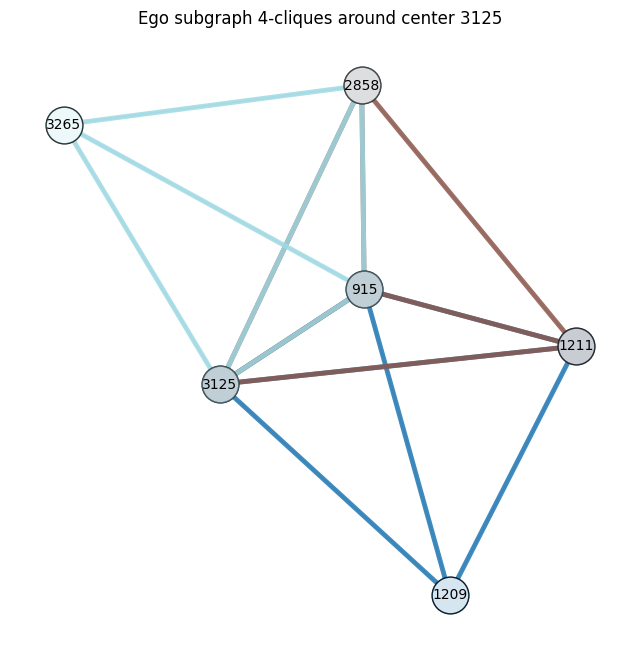

In [22]:

from itertools import combinations

def plot_ego_k4_overlay(H: nx.Graph, k4s, center=None, figsize=(8, 8), seed=7):
    """
    Plot the ego subgraph H.
    - All edges shown in light gray
    - Each 4-clique overlaid in a different color
    """
    if len(k4s) == 0:
        print("No 4-cliques to visualize.")
        return

    # Use only nodes that participate in at least one 4-clique
    clique_nodes = sorted(set().union(*k4s))
    S = H.subgraph(clique_nodes).copy()

    pos = nx.spring_layout(S, seed=seed)

    plt.figure(figsize=figsize)

    # Draw background graph
    nx.draw_networkx_edges(S, pos, edge_color="lightgray", width=1.5, alpha=0.8)
    nx.draw_networkx_nodes(S, pos, node_color="white", edgecolors="black", node_size=700)
    nx.draw_networkx_labels(S, pos, font_size=10)

    # Distinct colors for cliques
    cmap = plt.cm.get_cmap("tab20", max(len(k4s), 1))

    for i, clique in enumerate(k4s):
        clique_edges = list(combinations(clique, 2))
        color = cmap(i)

        # Draw clique edges in color
        nx.draw_networkx_edges(
            S,
            pos,
            edgelist=clique_edges,
            edge_color=[color],
            width=3.5,
            alpha=0.85
        )

        # Optional: tint clique nodes slightly too
        nx.draw_networkx_nodes(
            S,
            pos,
            nodelist=list(clique),
            node_color=[color],
            node_size=700,
            alpha=0.18
        )

    title = f"Ego subgraph 4-cliques around center {center}" if center is not None else "Ego subgraph 4-cliques"
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_ego_k4_overlay(H, k4s, center=center)

In [28]:
# just making sure these edges are really absent to show that there aren't more than 3 4-cliques in this ego graph

suspect_pairs = [
    (2858, 1209),
    (1211, 3265),
    (3265, 1209)
]

for u, v in suspect_pairs:
    print((u, v), "exists?" , H.has_edge(u, v))

(2858, 1209) exists? False
(1211, 3265) exists? False
(3265, 1209) exists? False


In [29]:
center = candidate_df.iloc[0]["center"] 
H = nx.ego_graph(G, center, radius=1)

k4s = [tuple(sorted(c)) for c in enumerate_k_cliques(H, 4)]

print(f"Chosen center: {center}")
print(f"Ego graph nodes: {H.number_of_nodes()}")
print(f"Ego graph edges: {H.number_of_edges()}")
print(f"4-clique count: {len(k4s)}")

pd.DataFrame({
    "clique_id": range(1, len(k4s) + 1),
    "nodes": k4s
})

Processing nodes: 100%|██████████| 6/6 [00:00<00:00, 42438.15it/s]

Chosen center: 3125
Ego graph nodes: 6
Ego graph edges: 12
4-clique count: 3


,clique_id,nodes
0,1,"(915, 1209, 1211, 3125)"
1,2,"(915, 1211, 2858, 3125)"
2,3,"(915, 2858, 3125, 3265)"


## Interpretation

4-clique density is stricter than triangle-based clustering. A graph can have many triangles and still have relatively little fully connected 4-node structure.

For realism testing later, matching 4-clique density means reproducing the prevalence of genuinely dense 4-node groups, not just wedge closure.